# GRPO 与可验证奖励 — 算术任务上的实验

验证 `grpo.tex` 中的核心结论：

1. **可验证奖励推翻系统性错误**：SFT 教师「不会进位」，基础模型在进位题上自信地全错（进位准确率 0）；规则判分的 RLVR 用约 20 轮把整体准确率从 0.30 拉到 1.00；
2. **奖励不可击穿**：β=0、无任何 KL 锚定地长训 600 轮——准确率到顶后稳定不动，KL 停在约 1 nat。对照第 12 章（学习奖励 β=0 崩塌）与第 13 章（DPO 软锚松动）：当奖励就是真实目标，锚成了可选项；
3. **冷启动之死**：教师从不给对进位题时，策略在进位题上采样成功率≈0——GRPO 的组内全体同分，优势恒为零，学习信号完全消失，准确率永远停在 0.30。

任务：两位数加法。提示为 `d d + d d =`（零填充），补全 3 位数字，奖励 = 规则验证对错（0/1）。策略是与前两章同构的小 Transformer（约 12 万参数），SFT 教师以 0.3 概率给出正确答案、0.7 概率给出**逐位相加不进位**的系统性错误答案——进位题上错误答案是数据众数，贪心解码自信地错。

GRPO：每个提示采样 G=8 个补全，组内标准化优势 $(r_i-\bar{r})/\mathrm{std}(r)$ 替代 Critic，PPO-clip 更新。组内均值与第 7 章的全局批基线同为基线的一种（本章未做两者对照）；组基线的决定性差异体现在实验 3 的零信号组占比上。

输出图：
- `fig1_rlvr_overturns.pdf`
- `fig2_unhackable_reward.pdf`
- `fig3_cold_start.pdf`

预计运行时间：GPU 约 10 分钟；CPU 约 40 分钟（3 seeds）。

In [ ]:
BREAKRL_CHAPTER = 'grpo'

import sys

if 'google.colab' in sys.modules:
    import runpy
    import urllib.request
    from pathlib import Path

    _setup = Path('/content/_breakrl_colab_setup.py')
    urllib.request.urlretrieve(
        'https://raw.githubusercontent.com/Powfu-zwx/BreakRL/main/scripts/colab_setup.py',
        _setup,
    )
    runpy.run_path(str(_setup))['setup'](BREAKRL_CHAPTER)


In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
})

BLUE  = '#2166AC'
RED   = '#D6604D'
GRAY  = '#808080'
FIGSIZE = (7.2, 4.8)
OUTDIR  = '.'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

DIGITS = 10
PLUS = 10
EQ = 11
BOS = 12
VOCAB = 13
PROMPT_LEN = 6          # d d + d d =
ANS_LEN = 3             # zero-padded sum 000..198
D_MODEL = 64
MAX_LEN = 1 + PROMPT_LEN + ANS_LEN
SEEDS = (42, 43, 44)


def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)


def make_prompts(n):
    a = torch.randint(0, 100, (n,), device=DEVICE)
    b = torch.randint(0, 100, (n,), device=DEVICE)
    p = torch.stack([a // 10, a % 10, torch.full_like(a, PLUS),
                     b // 10, b % 10, torch.full_like(a, EQ)], dim=1)
    return p, a, b


def answer_digits(sums):
    return torch.stack([sums // 100, (sums // 10) % 10, sums % 10], dim=1)


def no_carry_sum(a, b):
    """The teacher's systematic error: digit-wise addition without carrying."""
    units = (a % 10 + b % 10) % 10
    tens = (a // 10 + b // 10) % 10
    return tens * 10 + units


def has_carry(a, b):
    units_carry = a % 10 + b % 10 >= 10
    tens_carry = a // 10 + b // 10 + (a % 10 + b % 10) // 10 >= 10
    return units_carry | tens_carry


def verify(completions, a, b):
    """The verifiable reward: exact-match against the true sum (0/1)."""
    return (completions == answer_digits(a + b)).all(dim=1).float()


def style_axes(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)


print(f'Device: {DEVICE}')

Device: cuda


In [2]:
class TinyLM(nn.Module):
    """Prompt-conditioned causal Transformer (~120k params)."""

    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(VOCAB + 1, D_MODEL)
        self.pos = nn.Embedding(MAX_LEN, D_MODEL)
        layer = nn.TransformerEncoderLayer(D_MODEL, 4, 128, batch_first=True,
                                           dropout=0.0, norm_first=True)
        self.encoder = nn.TransformerEncoder(layer, 2, enable_nested_tensor=False)
        self.head = nn.Linear(D_MODEL, VOCAB)
        mask = torch.triu(torch.full((MAX_LEN, MAX_LEN), float('-inf')), 1)
        self.register_buffer('mask', mask)

    def logits(self, inp):
        L = inp.size(1)
        h = self.emb(inp) + self.pos(torch.arange(L, device=inp.device))
        h = self.encoder(h, mask=self.mask[:L, :L])
        return self.head(h)

    @torch.no_grad()
    def generate(self, prompts, greedy=False):
        n = prompts.size(0)
        inp = torch.cat([torch.full((n, 1), BOS, dtype=torch.long, device=DEVICE),
                         prompts], dim=1)
        outs = []
        for _ in range(ANS_LEN):
            logits = self.logits(inp)[:, -1]
            if greedy:
                nxt = logits.argmax(dim=-1, keepdim=True)
            else:
                nxt = torch.multinomial(F.softmax(logits, dim=-1), 1)
            outs.append(nxt)
            inp = torch.cat([inp, nxt], dim=1)
        return torch.cat(outs, dim=1)

    def completion_log_probs(self, prompts, completions):
        n = prompts.size(0)
        inp = torch.cat([torch.full((n, 1), BOS, dtype=torch.long, device=DEVICE),
                         prompts, completions[:, :-1]], dim=1)
        logits = self.logits(inp)[:, PROMPT_LEN:]
        return torch.log_softmax(logits, dim=-1).gather(
            2, completions.unsqueeze(2)).squeeze(2)

In [3]:
def train_sft(q_correct, steps=1200, batch=256, lr=3e-3):
    """SFT on a flawed teacher: correct with prob q, else the no-carry answer."""
    lm = TinyLM().to(DEVICE)
    opt = torch.optim.Adam(lm.parameters(), lr=lr)
    for _ in range(steps):
        prompts, a, b = make_prompts(batch)
        use_correct = torch.rand(batch, device=DEVICE) < q_correct
        sums = torch.where(use_correct, a + b, no_carry_sum(a, b))
        loss = -lm.completion_log_probs(prompts, answer_digits(sums)).mean()
        opt.zero_grad(); loss.backward(); opt.step()
    return lm


@torch.no_grad()
def eval_accuracy(lm, n=2048):
    """Greedy accuracy, overall and on carry prompts."""
    prompts, a, b = make_prompts(n)
    acc = verify(lm.generate(prompts, greedy=True), a, b)
    carry = has_carry(a, b)
    return acc.mean().item(), acc[carry].mean().item()

In [4]:
def grpo_finetune(sft, iters=300, n_prompts=32, group=8, k_epochs=2,
                  mb=64, clip=0.2, lr=1e-4, beta=0.0, eval_every=5):
    """GRPO: group-relative advantages from the verifiable reward, PPO-clip update.

    No critic, no reward model. beta=0 by default -- with a verifiable
    reward the KL anchor is optional (Figure 2).
    """
    policy = TinyLM().to(DEVICE)
    policy.load_state_dict(sft.state_dict())
    ref = TinyLM().to(DEVICE)
    ref.load_state_dict(sft.state_dict())
    ref.eval()
    opt = torch.optim.Adam(policy.parameters(), lr=lr)
    history = {'it': [], 'acc': [], 'acc_carry': [], 'reward': [], 'kl': [],
               'zero_groups': []}
    total = n_prompts * group
    for it in range(1, iters + 1):
        with torch.no_grad():
            prompts, a, b = make_prompts(n_prompts)
            prompts = prompts.repeat_interleave(group, dim=0)
            a = a.repeat_interleave(group)
            b = b.repeat_interleave(group)
            comp = policy.generate(prompts)
            r = verify(comp, a, b)
            rg = r.view(n_prompts, group)
            adv = ((rg - rg.mean(dim=1, keepdim=True)) /
                   (rg.std(dim=1, keepdim=True) + 1e-4)).view(-1)
            zero_frac = (rg.std(dim=1) < 1e-6).float().mean().item()
            lp_old = policy.completion_log_probs(prompts, comp)
            lp_ref = ref.completion_log_probs(prompts, comp)
            kl_seq = (lp_old - lp_ref).sum(dim=1)
            if beta > 0:
                adv = adv - beta * kl_seq
        for _ in range(k_epochs):
            perm = torch.randperm(total, device=DEVICE)
            for s in range(0, total, mb):
                idx = perm[s:s + mb]
                lp_new = policy.completion_log_probs(prompts[idx], comp[idx])
                ratio = torch.exp((lp_new - lp_old[idx]).sum(dim=1))
                s1 = ratio * adv[idx]
                s2 = torch.clamp(ratio, 1 - clip, 1 + clip) * adv[idx]
                loss = -torch.min(s1, s2).mean()
                opt.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(policy.parameters(), 1.0)
                opt.step()
        if it % eval_every == 0:
            acc, acc_carry = eval_accuracy(policy)
            history['it'].append(it)
            history['acc'].append(acc)
            history['acc_carry'].append(acc_carry)
            history['reward'].append(r.mean().item())
            history['kl'].append(kl_seq.mean().item())
            history['zero_groups'].append(zero_frac)
    return history

In [5]:
print('=== Weak SFT (teacher correct with prob 0.3), per seed ===')
runs = {}
for seed in SEEDS:
    set_seed(seed)
    weak = train_sft(q_correct=0.3)
    acc, acc_carry = eval_accuracy(weak)
    prompts, a, b = make_prompts(2048)
    sampled = verify(weak.generate(prompts), a, b).mean().item()
    runs[seed] = {'weak': weak, 'base_acc': acc, 'base_carry': acc_carry}
    print(f'  seed {seed}: greedy acc {acc:.3f} (carry {acc_carry:.3f}) | '
          f'sampled acc {sampled:.3f}')

=== Weak SFT (teacher correct with prob 0.3), per seed ===


  seed 42: greedy acc 0.303 (carry 0.000) | sampled acc 0.524


  seed 43: greedy acc 0.317 (carry 0.036) | sampled acc 0.488


  seed 44: greedy acc 0.326 (carry 0.040) | sampled acc 0.518


---
## Figure 1 — 可验证奖励推翻系统性错误

基础模型的错误不是噪声，是**算法性的**：教师不会进位，进位题上错误答案占数据的 70%，贪心解码自信地全错（进位准确率≈0）。学习奖励在这里无能为力——它从同一份有偏数据里学，只会把偏差学进去。规则判分不同：对就是对、错就是错。GRPO 用采样中残存的约 30% 正确率作为信号，约 20 轮把进位准确率从 0 拉到 1.0（3 seeds，阴影为 $\pm 1\sigma$）。

In [6]:
print('=== Experiment 1: GRPO from the weak SFT ===')
for seed in SEEDS:
    set_seed(seed + 2000)
    runs[seed]['weak_hist'] = grpo_finetune(runs[seed]['weak'])
    h = runs[seed]['weak_hist']
    print(f"  seed {seed}: acc {runs[seed]['base_acc']:.2f} -> {h['acc'][-1]:.2f} | "
          f"carry {runs[seed]['base_carry']:.2f} -> {h['acc_carry'][-1]:.2f}")

=== Experiment 1: GRPO from the weak SFT ===


  seed 42: acc 0.30 -> 1.00 | carry 0.00 -> 1.00


  seed 43: acc 0.32 -> 1.00 | carry 0.04 -> 1.00


  seed 44: acc 0.33 -> 1.00 | carry 0.04 -> 1.00


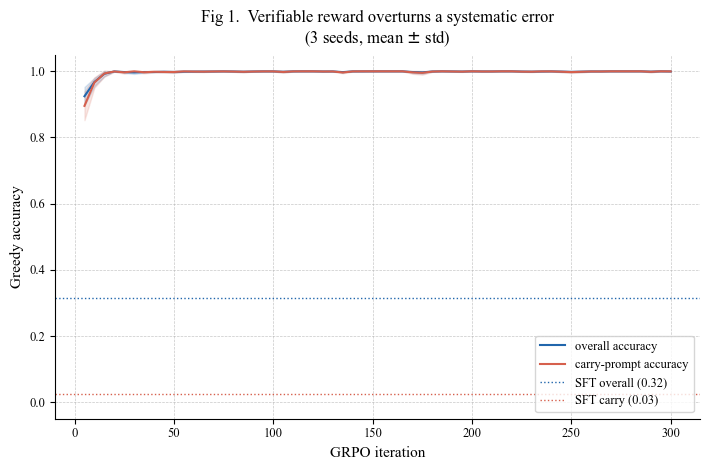

Saved fig1_rlvr_overturns.pdf


In [7]:
def stack(key, hist_key='weak_hist'):
    return np.array([runs[s][hist_key][key] for s in SEEDS])

fig, ax = plt.subplots(figsize=FIGSIZE)
its = np.array(runs[SEEDS[0]]['weak_hist']['it'])

for key, color, label in [('acc', BLUE, 'overall accuracy'),
                          ('acc_carry', RED, 'carry-prompt accuracy')]:
    curve = stack(key)
    ax.plot(its, curve.mean(0), color=color, linewidth=1.5, label=label)
    ax.fill_between(its, curve.mean(0) - curve.std(0),
                    curve.mean(0) + curve.std(0), color=color, alpha=0.15)

base_acc = np.mean([runs[s]['base_acc'] for s in SEEDS])
base_carry = np.mean([runs[s]['base_carry'] for s in SEEDS])
ax.axhline(base_acc, color=BLUE, linestyle=':', linewidth=1.0,
           label=f'SFT overall ({base_acc:.2f})')
ax.axhline(base_carry, color=RED, linestyle=':', linewidth=1.0,
           label=f'SFT carry ({base_carry:.2f})')

style_axes(ax)
ax.set_xlabel('GRPO iteration')
ax.set_ylabel('Greedy accuracy')
ax.set_ylim(-0.05, 1.05)
ax.set_title('Fig 1.  Verifiable reward overturns a systematic error\n'
             '(3 seeds, mean $\\pm$ std)', pad=8)
ax.legend(loc='lower right')
fig.tight_layout()
fig.savefig(f'{OUTDIR}/fig1_rlvr_overturns.pdf', bbox_inches='tight')
plt.show()
print('Saved fig1_rlvr_overturns.pdf')

---
## Figure 2 — 不可击穿的奖励：β=0 长训不崩

第 12 章里 β=0 的 PPO 在 60 轮内击穿学习奖励，第 13 章里 DPO 的软锚随训练松动。这里同样 β=0、训练 600 轮——什么都没发生：准确率到顶后纹丝不动，KL 稳定在约 1 nat。原因很简单：**奖励与真实目标是同一个函数**，代理与真实之间没有可分叉的缝隙，优化再狠也只能把正确答案学得更牢。「奖励被击穿」在 RLVR 里从定义上不可能——剩下的风险只在验证器本身有没有漏洞（3 seeds，阴影为 $\pm 1\sigma$）。

In [8]:
print('=== Experiment 2: beta = 0, 600 iterations, nothing collapses ===')
for seed in SEEDS:
    set_seed(seed + 3000)
    runs[seed]['long_hist'] = grpo_finetune(runs[seed]['weak'], iters=600)
    h = runs[seed]['long_hist']
    print(f"  seed {seed}: final acc {h['acc'][-1]:.3f} | "
          f"final KL {h['kl'][-1]:.2f} | max KL {max(h['kl']):.2f}")

=== Experiment 2: beta = 0, 600 iterations, nothing collapses ===


  seed 42: final acc 1.000 | final KL 0.95 | max KL 1.32


  seed 43: final acc 1.000 | final KL 0.86 | max KL 1.39


  seed 44: final acc 0.999 | final KL 0.84 | max KL 1.15


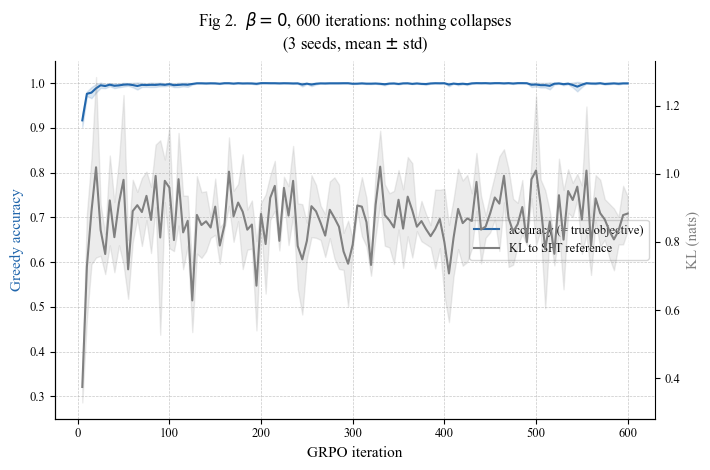

Saved fig2_unhackable_reward.pdf


In [9]:
fig, ax = plt.subplots(figsize=FIGSIZE)
its = np.array(runs[SEEDS[0]]['long_hist']['it'])

acc = stack('acc', 'long_hist')
ax.plot(its, acc.mean(0), color=BLUE, linewidth=1.5, label='accuracy (= true objective)')
ax.fill_between(its, acc.mean(0) - acc.std(0), acc.mean(0) + acc.std(0),
                color=BLUE, alpha=0.15)
ax.set_xlabel('GRPO iteration')
ax.set_ylabel('Greedy accuracy', color=BLUE)
ax.set_ylim(0.25, 1.05)

ax2 = ax.twinx()
kl = stack('kl', 'long_hist')
ax2.plot(its, kl.mean(0), color=GRAY, linewidth=1.5, label='KL to SFT reference')
ax2.fill_between(its, kl.mean(0) - kl.std(0), kl.mean(0) + kl.std(0),
                 color=GRAY, alpha=0.15)
ax2.set_ylabel('KL (nats)', color=GRAY)

style_axes(ax)
ax2.spines['top'].set_visible(False)
ax.set_title('Fig 2.  $\\beta=0$, 600 iterations: nothing collapses\n'
             '(3 seeds, mean $\\pm$ std)', pad=8)
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc='center right')
fig.tight_layout()
fig.savefig(f'{OUTDIR}/fig2_unhackable_reward.pdf', bbox_inches='tight')
plt.show()
print('Saved fig2_unhackable_reward.pdf')

---
## Figure 3 — 冷启动之死：全组同分，学习信号为零

GRPO 的优势来自组内对比：$(r_i-\bar{r})/\mathrm{std}(r)$。对比就需要**组内有差异**。把教师换成从不给对进位题（q=0）：冷启动模型在进位题上采样成功率≈0，每个组要么全对（简单题）要么全错（进位题），组内标准差为零——优势恒为零，梯度恒为零。右图的零信号组占比：冷启动恒为 100%，学习从未开始；弱教师起点则从约三成一路升到接近 100%——那是另一种含义：题目全部练会，「毕业」了。同一个统计量，两种命运。这就是推理模型训练需要冷启动 SFT 数据的原因（3 seeds，阴影为 $\pm 1\sigma$）。

In [10]:
print('=== Experiment 3: cold start (teacher never correct on carries) ===')
for seed in SEEDS:
    set_seed(seed + 4000)
    cold = train_sft(q_correct=0.0)
    acc, acc_carry = eval_accuracy(cold)
    set_seed(seed + 5000)
    runs[seed]['cold_hist'] = grpo_finetune(cold)
    h = runs[seed]['cold_hist']
    print(f'  seed {seed}: cold SFT acc {acc:.3f} (carry {acc_carry:.3f}) -> '
          f"GRPO final {h['acc'][-1]:.3f} | zero-signal groups "
          f"{h['zero_groups'][-1]:.2f}")

=== Experiment 3: cold start (teacher never correct on carries) ===


  seed 42: cold SFT acc 0.294 (carry 0.000) -> GRPO final 0.320 | zero-signal groups 1.00


  seed 43: cold SFT acc 0.311 (carry 0.000) -> GRPO final 0.292 | zero-signal groups 1.00


  seed 44: cold SFT acc 0.305 (carry 0.000) -> GRPO final 0.296 | zero-signal groups 1.00


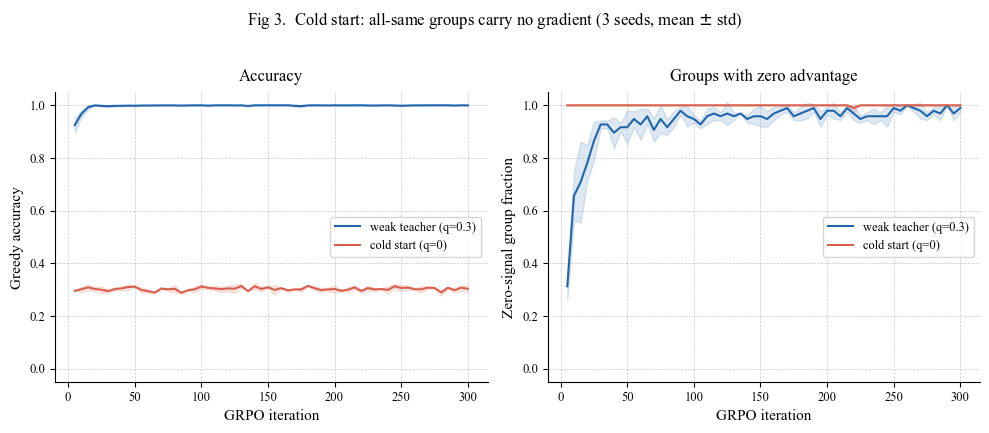

Saved fig3_cold_start.pdf


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
its = np.array(runs[SEEDS[0]]['weak_hist']['it'])

ax = axes[0]
for hist_key, color, label in [('weak_hist', BLUE, 'weak teacher (q=0.3)'),
                               ('cold_hist', RED, 'cold start (q=0)')]:
    acc = stack('acc', hist_key)
    ax.plot(its, acc.mean(0), color=color, linewidth=1.5, label=label)
    ax.fill_between(its, acc.mean(0) - acc.std(0), acc.mean(0) + acc.std(0),
                    color=color, alpha=0.15)
style_axes(ax)
ax.set_xlabel('GRPO iteration')
ax.set_ylabel('Greedy accuracy')
ax.set_ylim(-0.05, 1.05)
ax.set_title('Accuracy', pad=8)
ax.legend(loc='center right')

ax = axes[1]
for hist_key, color, label in [('weak_hist', BLUE, 'weak teacher (q=0.3)'),
                               ('cold_hist', RED, 'cold start (q=0)')]:
    z = stack('zero_groups', hist_key)
    ax.plot(its, z.mean(0), color=color, linewidth=1.5, label=label)
    ax.fill_between(its, z.mean(0) - z.std(0), z.mean(0) + z.std(0),
                    color=color, alpha=0.15)
style_axes(ax)
ax.set_xlabel('GRPO iteration')
ax.set_ylabel('Zero-signal group fraction')
ax.set_ylim(-0.05, 1.05)
ax.set_title('Groups with zero advantage', pad=8)
ax.legend(loc='center right')

fig.suptitle('Fig 3.  Cold start: all-same groups carry no gradient '
             '(3 seeds, mean $\\pm$ std)', y=1.02)
fig.tight_layout()
fig.savefig(f'{OUTDIR}/fig3_cold_start.pdf', bbox_inches='tight')
plt.show()
print('Saved fig3_cold_start.pdf')

## 小结

- **可验证奖励换掉了病根**：第 11、12 章的一切麻烦都源于「奖励是从有限覆盖的数据里学出来的代理」；当任务对错可以规则判定，代理与真实合二为一，reward hacking 从定义上不可能——β=0 长训不崩，锚成为可选项；
- **GRPO 用组内对比替代 Critic**：同一提示采样一组、组内标准化优势——按提示难度自动归一，不需要价值网络；组机制的独特行为体现在零信号组上（本章未与全局批基线做对照）；
- **新的瓶颈是信号，不是奖励**：可验证奖励通常稀疏（对/错），组内全体同分时优势恒为零——冷启动模型学习信号完全消失。修复靠起点与数据：冷启动 SFT、课程设计、混合难度保持组内方差；
- **三章弧线收束**：RLHF 教会我们「奖励可以学，但会被击穿」；DPO 教会我们「绕开组件绕不开覆盖区」；RLVR 教会我们「能验证就别学」——奖励的可靠性排序从此清晰：规则验证 > 人类偏好建模 > 手工设计。